**UNIVERSIDADE DE SÃO PAULO**<br>
**MBA DATA SCIENCE & ANALYTICS USP/ESALQ**<br>
**Encontro para resolução de exercícios adicionais: Árvores e Ensemble Models**<br>
**Prof. Dr. Wilson Tarantin Junior**<br>
Aluna: Luiza Batista Laquini<br>
Turma: DSA 241<br>

*coding: utf-8*

In [27]:
#%% Importar os pacotes

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
#from sklearn.ensemble import RandomForestRegressor
#from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [28]:
#%% Importar o banco de dados

dados = pd.read_excel('data/dados_admissao.xlsx')
# Fonte: adaptado de https://www.kaggle.com/datasets/mohansacharya/graduate-admissions
# Mohan S Acharya, Asfia Armaan, Aneeta S Antony: A Comparison of Regression Models for Prediction of Graduate Admissions, IEEE International Conference on Computational Intelligence in Data Science 2019

In [29]:
dados.head()

,Serial No.,GRE,TOEFL,UniversityRating,SOP,LOR,CGPA,Research,Score
0,1,337,118,4,4.5,4.5,9.65,1,92.0
1,2,324,107,4,4.0,4.5,8.87,1,76.0
2,3,316,104,3,3.0,3.5,8.00,1,72.0
3,4,322,110,3,3.5,2.5,8.67,1,80.0
4,5,314,103,2,2.0,3.0,8.21,0,65.0


In [30]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Serial No.        500 non-null    int64  
 1   GRE               500 non-null    int64  
 2   TOEFL             500 non-null    int64  
 3   UniversityRating  500 non-null    int64  
 4   SOP               500 non-null    float64
 5   LOR               500 non-null    float64
 6   CGPA              500 non-null    float64
 7   Research          500 non-null    int64  
 8   Score             500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [31]:
#%% Limpeza dos dados

# Remover colunas que não serão utilizadas
dados.drop(columns=['Serial No.'], inplace=True)

In [32]:
#%% Estatísticas descritivas das variáveis

# Variáveis métricas
print(dados[['GRE', 'TOEFL', 'SOP', 'LOR', 'CGPA', 'Score']].describe(),'\n')

# Variáveis categóricas
print(dados['UniversityRating'].value_counts(),'\n')
print(dados['Research'].value_counts(),'\n')

              GRE       TOEFL         SOP        LOR        CGPA      Score
count  500.000000  500.000000  500.000000  500.00000  500.000000  500.00000
mean   316.472000  107.192000    3.374000    3.48400    8.576440   72.17400
std     11.295148    6.081868    0.991004    0.92545    0.604813   14.11404
min    290.000000   92.000000    1.000000    1.00000    6.800000   34.00000
25%    308.000000  103.000000    2.500000    3.00000    8.127500   63.00000
50%    317.000000  107.000000    3.500000    3.50000    8.560000   72.00000
75%    325.000000  112.000000    4.000000    4.00000    9.040000   82.00000
max    340.000000  120.000000    5.000000    5.00000    9.920000   97.00000 

UniversityRating
3    162
2    126
4    105
5     73
1     34
Name: count, dtype: int64 

Research
1    280
0    220
Name: count, dtype: int64 



In [33]:
#%% Transformando variáveis explicativas categóricas em dummies

dados = pd.get_dummies(dados, 
                       columns=['UniversityRating'], 
                       drop_first=False,
                       dtype='int')

# Note que Research já é uma dummy!

In [34]:
#%% Separando as variáveis Y e X

X = dados.drop(columns=['Score'])
y = dados['Score']

In [35]:
#%% Separando as amostras de treino e teste

# Vamos escolher 70% das observações para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=100)

In [36]:
#%%######################### Árvore de Decisão ################################
###############################################################################
#%% Gerando a árvore de decisão

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=100)
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=100)

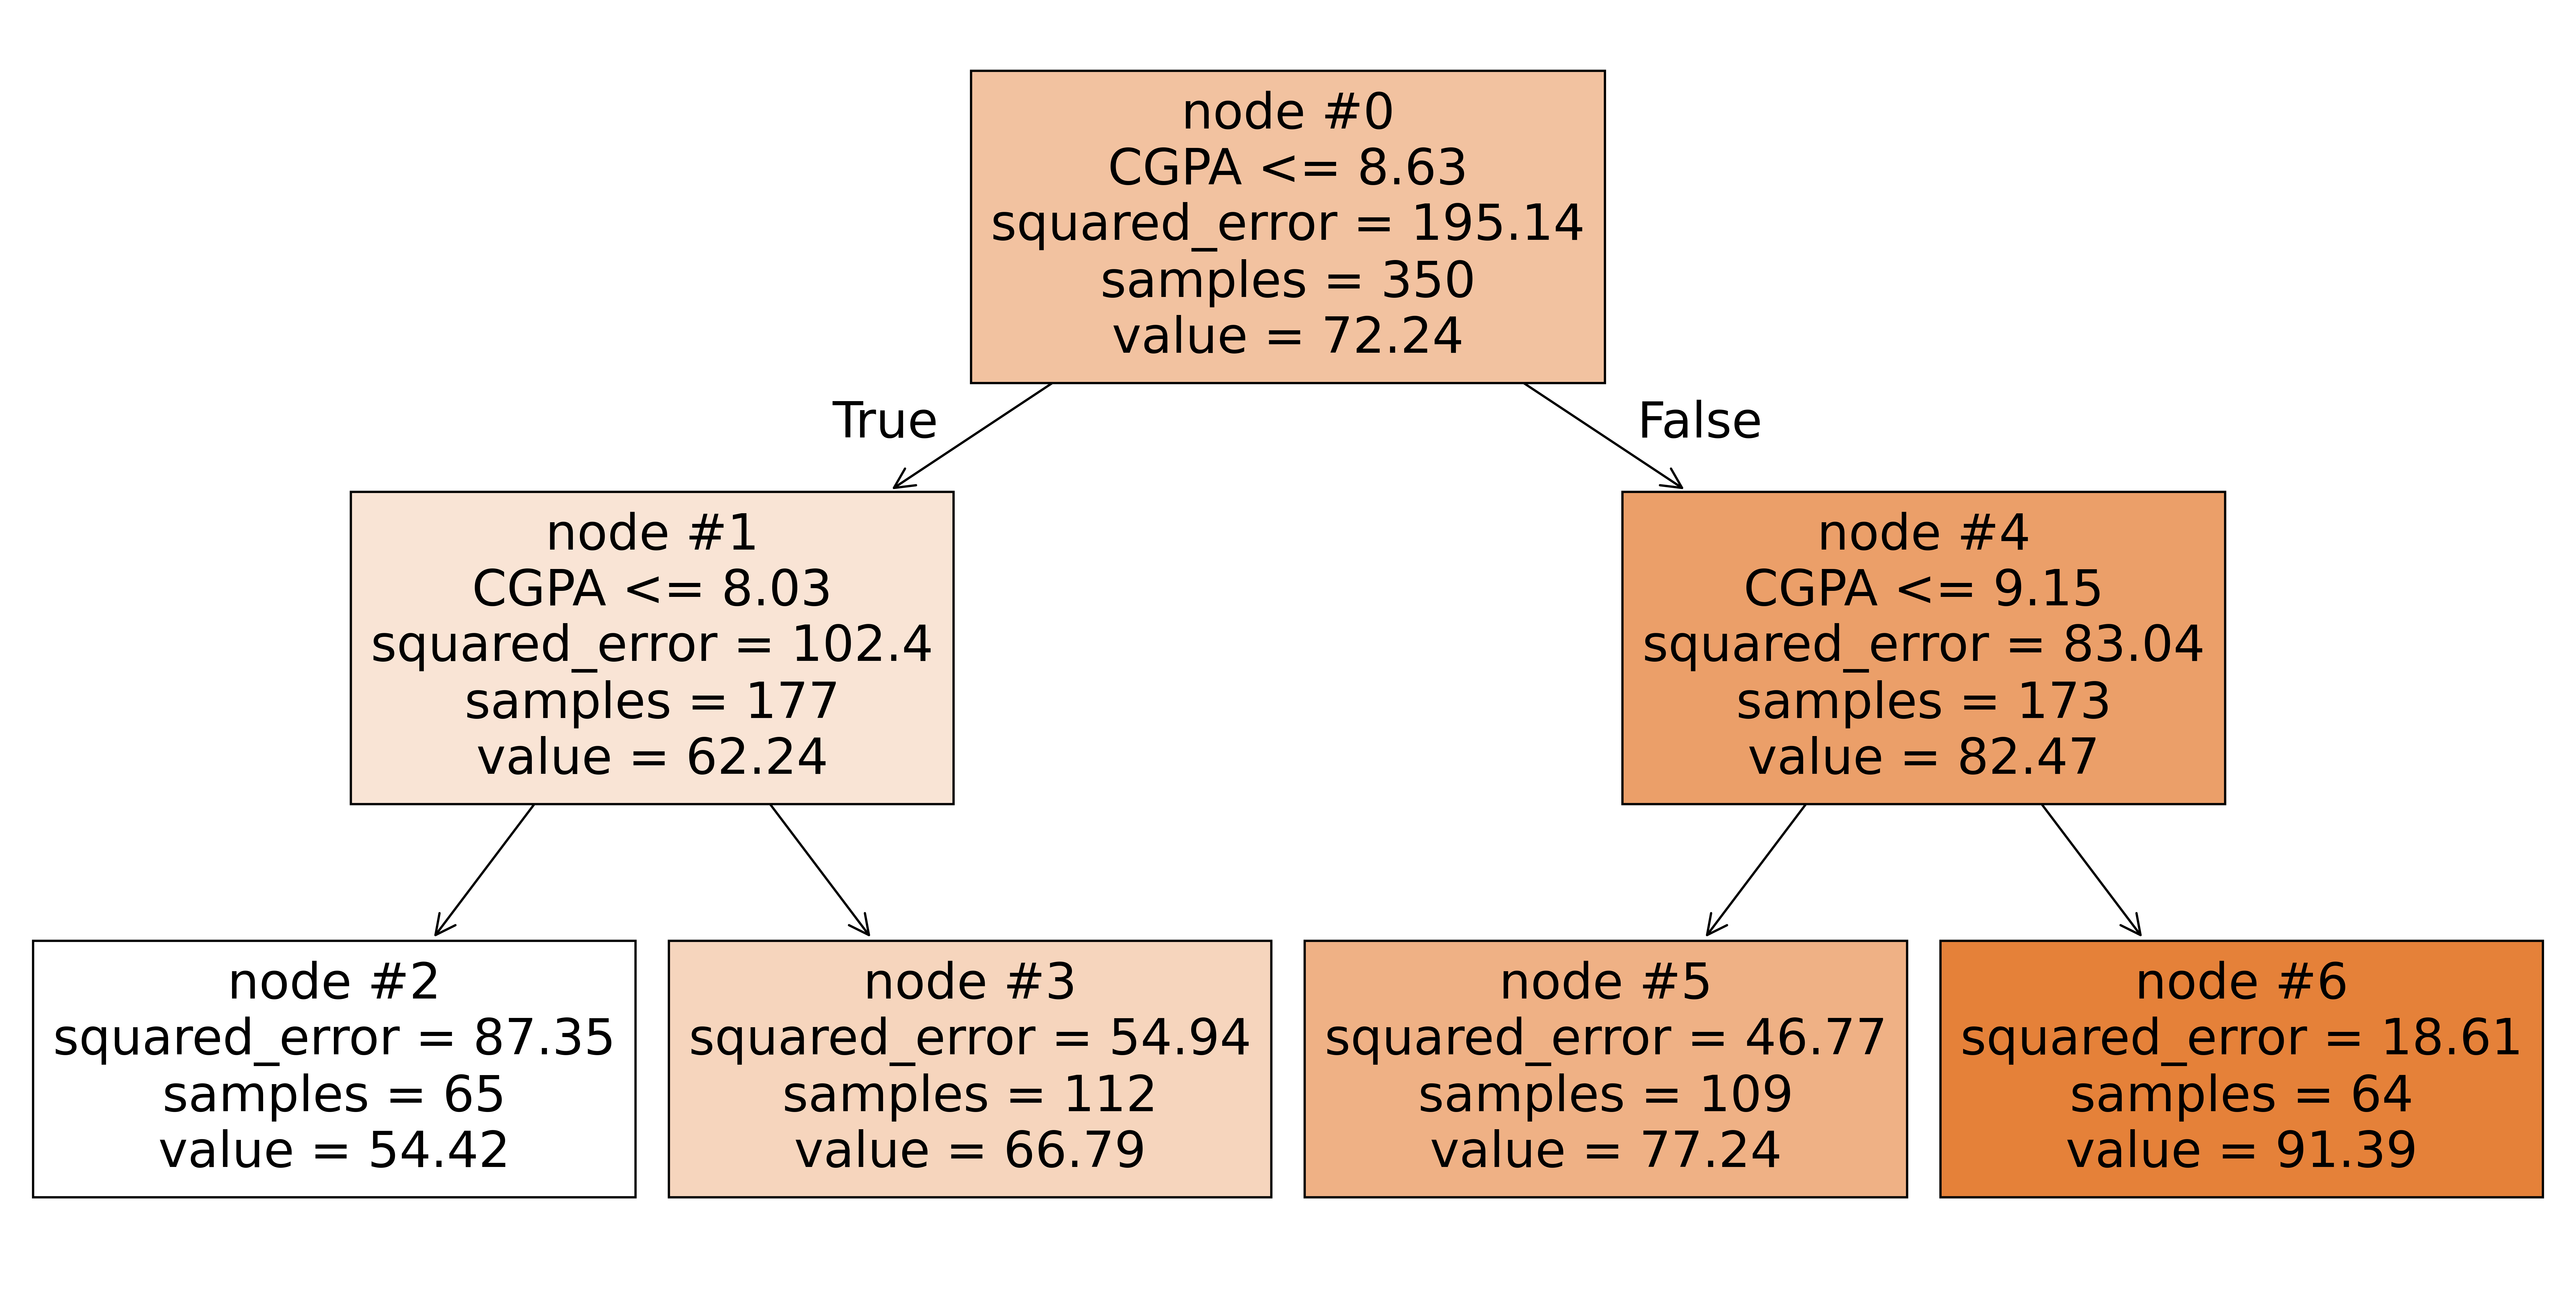

In [37]:
#%% Plotando a árvore

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_reg,
          feature_names=X.columns.tolist(),
          filled=True,
          node_ids=True,
          precision=2)
plt.show()

In [38]:
#%% Analisando os resultados dos splits

tree_split = pd.DataFrame(tree_reg.cost_complexity_pruning_path(X_train, y_train))
tree_split.sort_index(ascending=False, inplace=True)

print(tree_split)

   ccp_alphas  impurities
3  102.310487  195.138163
2   23.074573   92.827676
1   17.982605   69.753103
0    0.000000   51.770498


In [39]:
#%% Importância das variáveis preditoras

tree_features = pd.DataFrame({'features':X.columns.tolist(),
                              'importance':tree_reg.feature_importances_})

print(tree_features)

              features  importance
0                  GRE         0.0
1                TOEFL         0.0
2                  SOP         0.0
3                  LOR         0.0
4                 CGPA         1.0
5             Research         0.0
6   UniversityRating_1         0.0
7   UniversityRating_2         0.0
8   UniversityRating_3         0.0
9   UniversityRating_4         0.0
10  UniversityRating_5         0.0


In [40]:
#%% Obtendo os valores preditos pelo modelo

# Base de treinamento
tree_pred_train = tree_reg.predict(X_train)

# Base de teste
tree_pred_test = tree_reg.predict(X_test)

#%% Avaliando o modelo (base de treino)

mse_train_tree = mean_squared_error(y_train, tree_pred_train)
mae_train_tree = mean_absolute_error(y_train, tree_pred_train)
r2_train_tree = r2_score(y_train, tree_pred_train)

print("Avaliação do Modelo (Base de Treino)")
print(f"MSE: {mse_train_tree:.1f}")
print(f"RMSE: {np.sqrt(mse_train_tree):.1f}")
print(f"MAE: {mae_train_tree:.1f}")
print(f"R²: {r2_train_tree:.1%}")

Avaliação do Modelo (Base de Treino)
MSE: 51.8
RMSE: 7.2
MAE: 5.4
R²: 73.5%


In [41]:
#%% Avaliando o modelo (base de testes)

mse_test_tree = mean_squared_error(y_test, tree_pred_test)
mae_test_tree = mean_absolute_error(y_test, tree_pred_test)
r2_test_tree = r2_score(y_test, tree_pred_test)

print("Avaliação do Modelo (Base de Teste)")
print(f"MSE: {mse_test_tree:.1f}")
print(f"RMSE: {np.sqrt(mse_test_tree):.1f}")
print(f"MAE: {mae_test_tree:.1f}")
print(f"R²: {r2_test_tree:.1%}")

Avaliação do Modelo (Base de Teste)
MSE: 55.2
RMSE: 7.4
MAE: 5.8
R²: 73.4%


In [42]:
#%% Alguns hiperparâmetros do modelo

# max_depth: profundidade máxima da árvore
# min_samples_split: qtde mínima de observações para dividir o nó
# min_samples_leaf: qtde mínima de observações para ser nó folha

# Vamos aplicar um Grid Search
param_grid_tree = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [5, 10]
}

# Identificar o algoritmo em uso
tree_grid = DecisionTreeRegressor(random_state=100)

# Treinar os modelos para o grid search
tree_grid_model = GridSearchCV(estimator = tree_grid, 
                               param_grid = param_grid_tree,
                               scoring='neg_mean_squared_error', # Atenção à metrica de avaliação!
                               cv=5, verbose=2)

tree_grid_model.fit(X_train, y_train)

# Verificando os melhores parâmetros obtidos
tree_grid_model.best_params_

# Gerando o modelo com os melhores hiperparâmetros
tree_best = tree_grid_model.best_estimator_

# Predict do modelo
tree_grid_pred_train = tree_best.predict(X_train)
tree_grid_pred_test = tree_best.predict(X_test)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=5, min_samples_split=15; total time=   0.0s
[CV] END max_depth=3, min_sampl

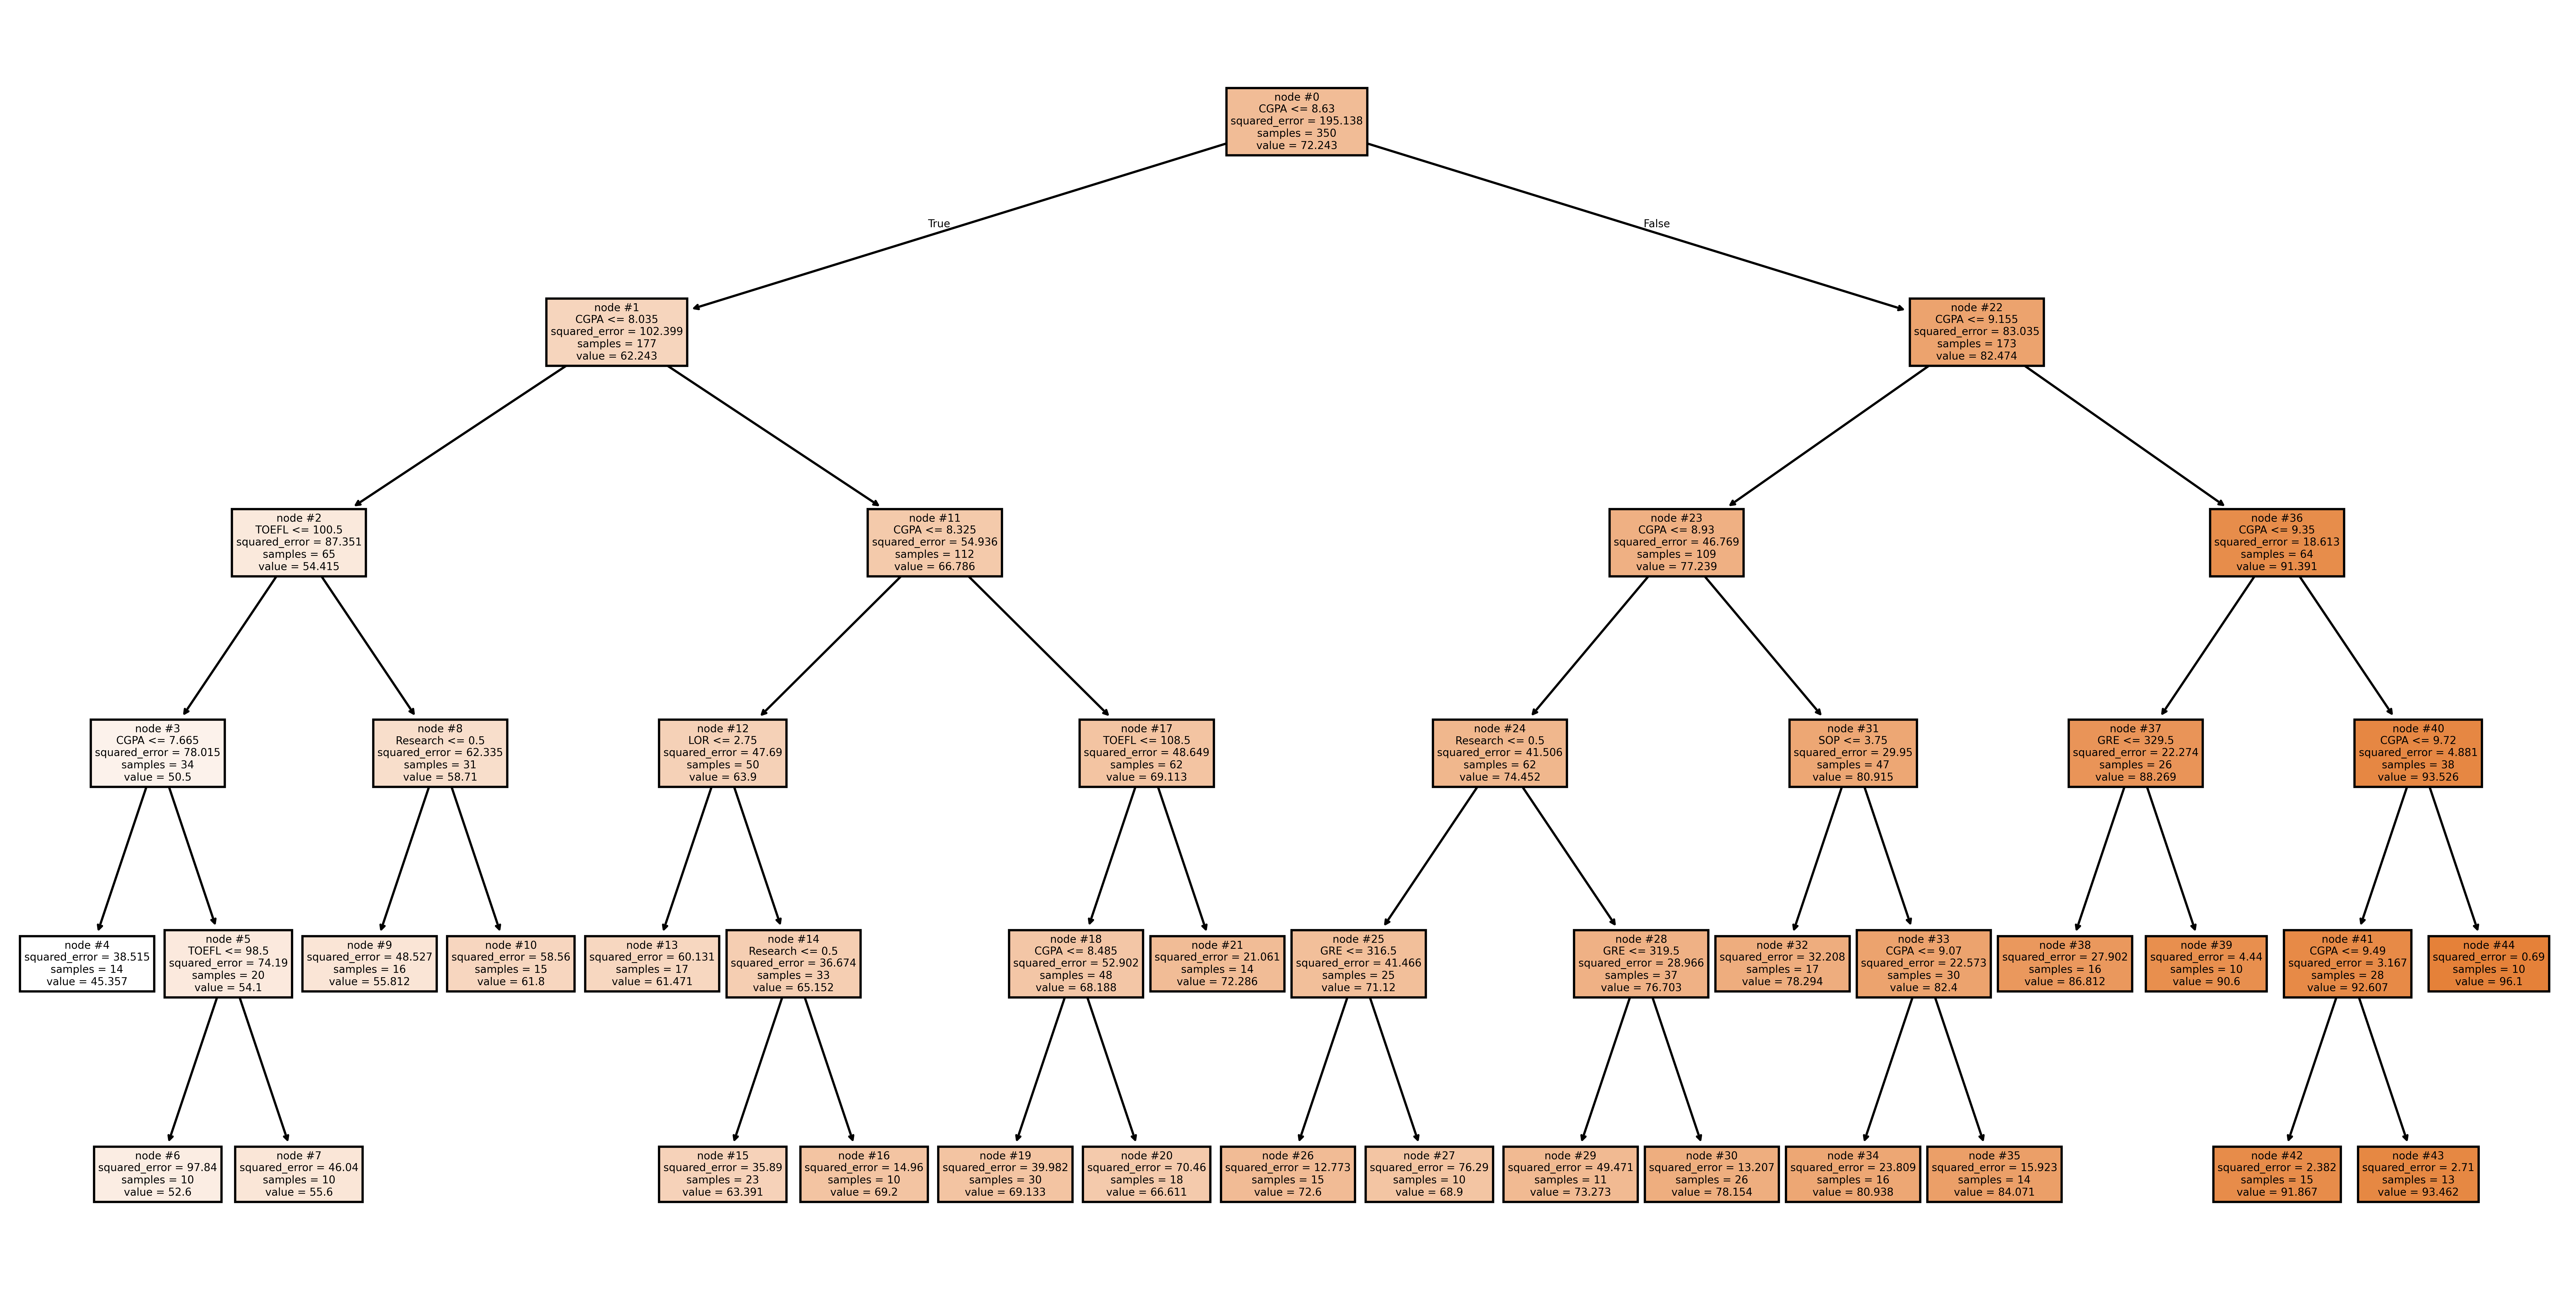

In [43]:
#%% Plotando a árvore após o grid search

plt.figure(figsize=(20,10), dpi=600)
plot_tree(tree_best,
          feature_names=X.columns.tolist(),
          filled=True,
          node_ids=True)
plt.show()

In [44]:
#%% Avaliando o novo modelo (base de treino)

mse_train_tree_grid = mean_squared_error(y_train, tree_grid_pred_train)
mae_train_tree_grid = mean_absolute_error(y_train, tree_grid_pred_train)
r2_train_tree_grid = r2_score(y_train, tree_grid_pred_train)

print("Avaliação do Modelo (Base de Treino)")
print(f"MSE: {mse_train_tree_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_train_tree_grid):.1f}")
print(f"MAE: {mae_train_tree_grid:.1f}")
print(f"R²: {r2_train_tree_grid:.1%}")

Avaliação do Modelo (Base de Treino)
MSE: 34.2
RMSE: 5.8
MAE: 4.2
R²: 82.5%


In [45]:
#%% Avaliando o novo modelo (base de teste)

mse_test_tree_grid = mean_squared_error(y_test, tree_grid_pred_test)
mae_test_tree_grid = mean_absolute_error(y_test, tree_grid_pred_test)
r2_test_tree_grid = r2_score(y_test, tree_grid_pred_test)

print("Avaliação do Modelo (Base de Teste)")
print(f"MSE: {mse_test_tree_grid:.1f}")
print(f"RMSE: {np.sqrt(mse_test_tree_grid):.1f}")
print(f"MAE: {mae_test_tree_grid:.1f}")
print(f"R²: {r2_test_tree_grid:.1%}")

Avaliação do Modelo (Base de Teste)
MSE: 44.0
RMSE: 6.6
MAE: 5.0
R²: 78.8%


In [46]:
#%% Importância das variáveis preditoras

tree_features = pd.DataFrame({'features':X.columns.tolist(),
                              'importance':tree_best.feature_importances_}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print(tree_features)

              features  importance
0                 CGPA    0.946983
1                TOEFL    0.023427
2             Research    0.017352
3                  GRE    0.006293
4                  SOP    0.003247
5                  LOR    0.002698
6   UniversityRating_1    0.000000
7   UniversityRating_2    0.000000
8   UniversityRating_3    0.000000
9   UniversityRating_4    0.000000
10  UniversityRating_5    0.000000


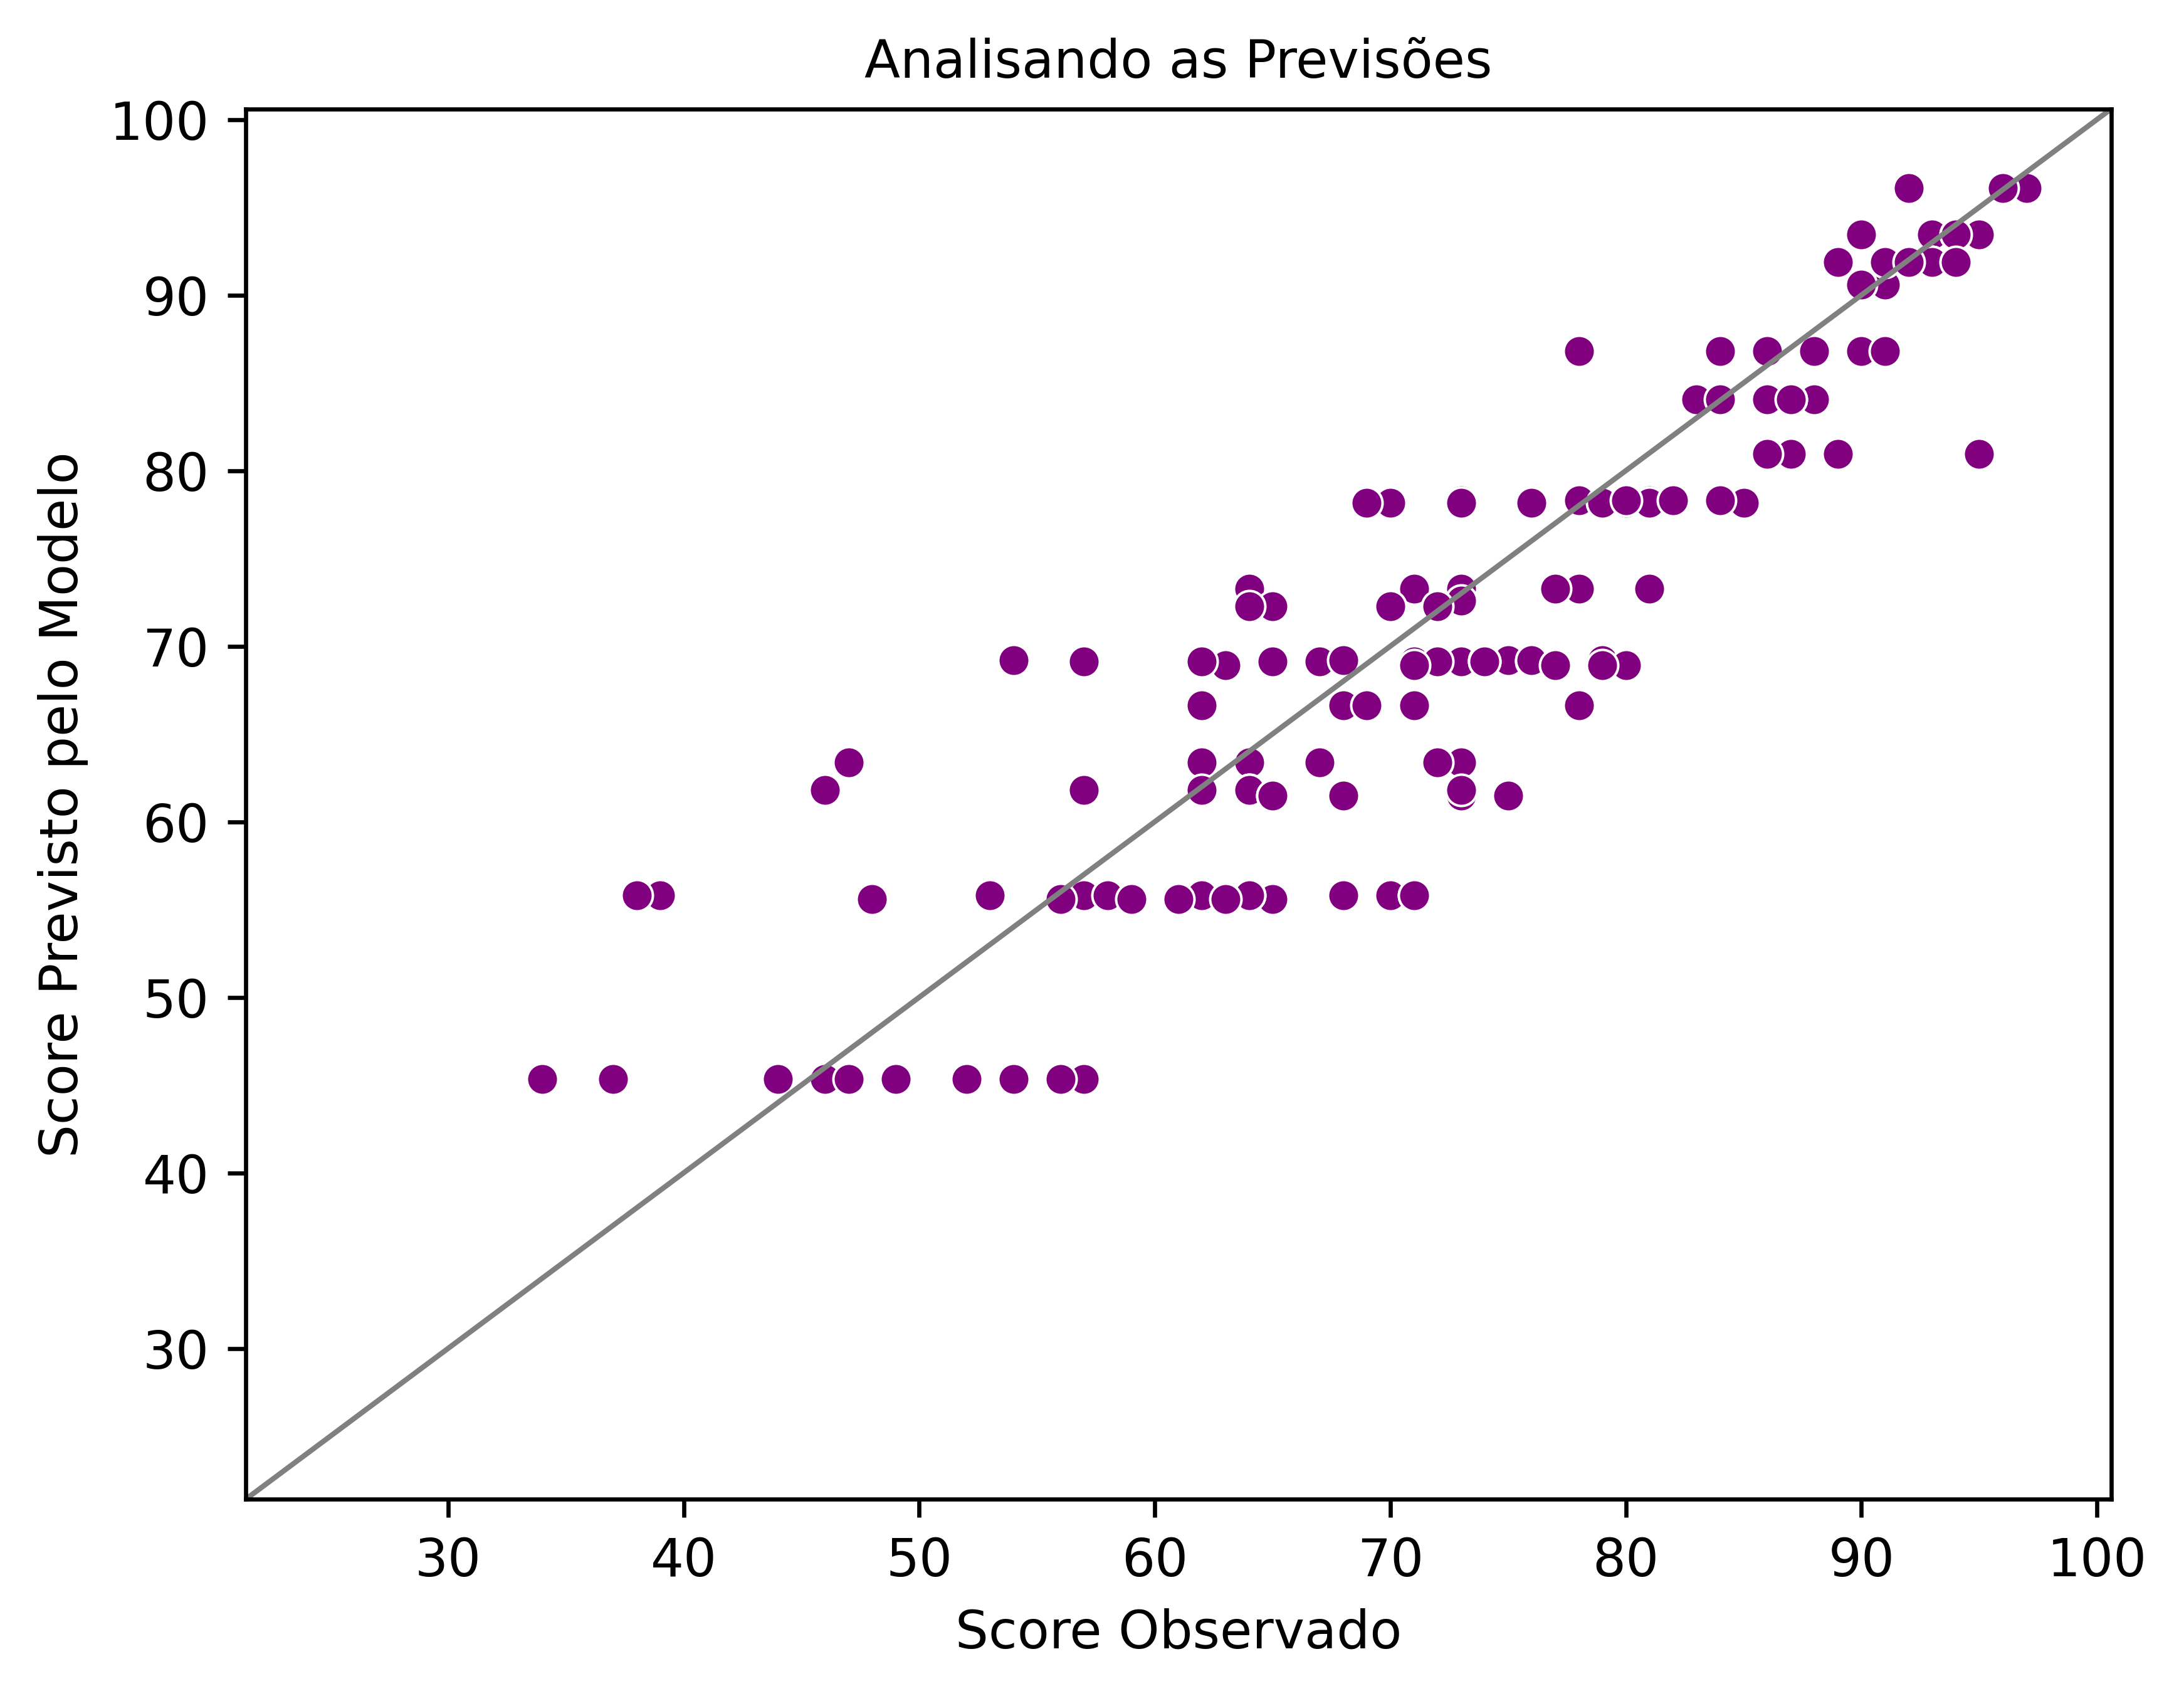

In [47]:
#%% Gráfico fitted values

# Valores preditos pelo modelo para as observações da amostra de teste
graph = pd.DataFrame({'Score': y_test,
                      'pred_tree': tree_grid_pred_test})

plt.figure(dpi=600)
sns.scatterplot(graph, x='Score', y='pred_tree', color='purple')
plt.title('Analisando as Previsões', fontsize=10)
plt.xlabel('Score Observado', fontsize=10)
plt.ylabel('Score Previsto pelo Modelo', fontsize=10)
plt.axline((25, 25), (max(dados['Score']), max(dados['Score'])), linewidth=1, color='grey')
plt.show()

In [48]:
#%% Quais poderiam ser os próximos passos?

# Caso o intuito seja melhorar as previsões é possível avaliar outros modelos:
    # Random Forest: RandomForestRegressor()
    # XGBoost: XGBRegressor()

#%% Fim!